In [25]:
import zipfile
import os

# 1. Sửa lại đường dẫn trực tiếp trên Colab (bỏ đoạn drive/MyDrive)
zip_path = "/content/drive/MyDrive/tien.zip"
extract_path = "/content/tien_dataset/"

# 2. Tiến hành giải nén tự động
if not os.path.exists(extract_path):
    print("Đang giải nén dữ liệu, vui lòng đợi...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Giải nén thành công vào thư mục:", extract_path)
else:
    print("Dữ liệu đã được giải nén từ trước.")

# 3. Tự động xóa file thừa ngtrdaiDataset.data
file_to_remove = "/content/tien_dataset/dataset/ngtrdaiDataset.data"
if os.path.exists(file_to_remove):
    os.remove(file_to_remove)
    print("Đã xóa file cấu trúc thừa ngtrdaiDataset.data")

Dữ liệu đã được giải nén từ trước.


In [26]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# 1. TIỀN XỬ LÝ DỮ LIỆU
# Thiết lập đường dẫn dữ liệu
train_dir = "/content/drive/MyDrive/tien.zip"

# Kích thước ảnh và kích thước lô
img_width, img_height = 192, 144
batch_size = 32

# Tăng cường dữ liệu dành cho huấn luyện mô hình
train_datagen = ImageDataGenerator(
    rescale=1.0/255, # Normalize pixel values
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest",
    validation_split=0.2
)

In [27]:
train_dir = "/content/tien_dataset/dataset"

In [28]:
# Tải dữ liệu huấn luyện
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode="categorical"
)

validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation"
)

# XÂY DỰNG MÔ HÌNH CNN
model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(img_width, img_height, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),  # Giảm overfitting
    Dense(12, activation="softmax")
])


Found 2712 images belonging to 12 classes.
Found 540 images belonging to 12 classes.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 190, 142, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 95, 71, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 93, 69, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 46, 34, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 44, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 22, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 45056)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     5,767,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,862,092 (22.36 MB)

 Trainable params: 5,862,092 (22.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 207s 2s/step - accuracy: 0.1486 - loss: 2.3999 - val_accuracy: 0.2593 - val_loss: 2.1409
Epoch 2/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 197s 2s/step - accuracy: 0.2673 - loss: 2.0570 - val_accuracy: 0.2722 - val_loss: 1.9072
Epoch 3/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 193s 2s/step - accuracy: 0.3142 - loss: 1.8673 - val_accuracy: 0.3741 - val_loss: 1.8079
Epoch 4/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 204s 2s/step - accuracy: 0.3433 - loss: 1.7748 - val_accuracy: 0.3796 - val_loss: 1.6436
Epoch 5/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 196s 2s/step - accuracy: 0.3831 - loss: 1.6529 - val_accuracy: 0.4259 - val_loss: 1.4836
Epoch 6/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 193s 2s/step - accuracy: 0.4023 - loss: 1.6408 - val_accuracy: 0.4019 - val_loss: 1.5394
Epoch 7/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 194s 2s/step - accuracy: 0.4259 - loss: 1.5302 - val_accuracy: 0.4352 - val_loss: 1.4664
Epoch 8/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 195s 2s/step - accuracy: 0.4443 - loss: 1.5161 - val_accuracy: 0.4389 - v

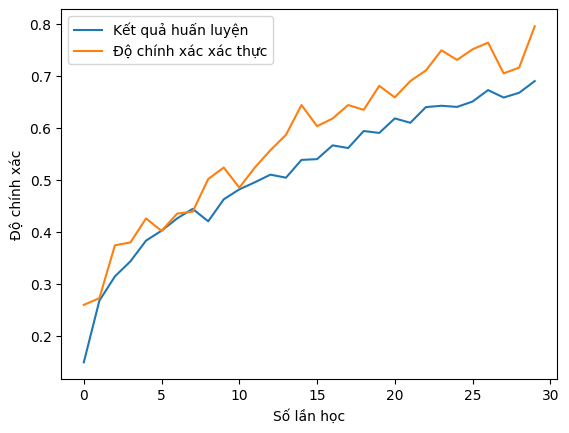

In [ ]:
# Biến dịch mô hình
model.compile(optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"])

# Tóm tắt cấu hình của mô hình
model.summary()

# HUẤN LUYỆN MÔ HÌNH CNN
history = model.fit(train_generator, epochs=30, validation_data=validation_generator)

# ĐÁNH GIÁ KẾT QUẢ MÔ HÌNH
plt.plot(history.history['accuracy'], label="Kết quả huấn luyện")
plt.plot(history.history['val_accuracy'], label="Độ chính xác xác thực")
plt.xlabel("Số lần học")
plt.ylabel("Độ chính xác")
plt.legend()
plt.show()

In [29]:
# Lưu trực tiếp vào bộ nhớ tạm của Colab
model.save('/content/mo_hinh_cnn_30_epochs.keras')
print("Đã lưu file vào bộ nhớ tạm của Colab!")

Đã lưu file vào bộ nhớ tạm của Colab!


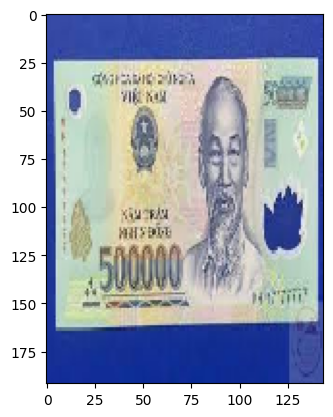

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Mệnh giá tiên đoán: 050000


In [32]:
# Tải và tiền xử lý ảnh kiểm tra
from keras.utils import load_img
import matplotlib.pyplot as plt
import numpy as np

path = "/content/to_500k.jpg"

# Tiên đoán loại s
img = load_img(path, target_size=(192, 144))
plt.imshow(img)
plt.show()

img = np.array(img)
img = img / 255.0
img = img.reshape(1, 192, 144, 3)

prediction = np.argmax(model.predict(img))

# Ánh xạ loại tới tên người
class_labels = {v: k for k, v in train_generator.class_indices.items()}
Menh_gia = class_labels[prediction]
print(f"Mệnh giá tiên đoán: {Menh_gia}")